In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import datetime as dt
import os

plt.style.use('seaborn-v0_8-whitegrid')

os.makedirs("project6-backtesting_rebalancing_charts", exist_ok=True)


end_date = dt.date.today()
start_date = end_date - dt.timedelta(days = 5*365)

stocks = ["AAPL", "KO", "^GSPC", "NVDA", "GC=F", "MSFT"]

df = yf.download(stocks, start= start_date, end = end_date)['Close']

df.head(10)

[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,GC=F,KO,MSFT,NVDA,^GSPC
Date,,,,,,
2021-08-04,143.239807,1810.500000,48.386700,274.962646,20.204117,4402.660156
2021-08-05,143.347000,1805.099976,48.731709,277.851440,20.565861,4429.100098
2021-08-06,142.663696,1760.000000,48.852467,277.793701,20.295799,4436.520020
2021-08-09,142.614838,1723.400024,48.861088,276.709290,20.225040,4432.350098
2021-08-10,142.136551,1728.800049,48.990452,274.895477,19.867285,4436.750000
2021-08-11,142.390335,1750.400024,48.930088,275.384949,19.631102,4442.410156
2021-08-12,145.348251,1749.000000,49.024960,278.129669,19.836390,4460.830078
2021-08-13,145.553268,1775.199951,49.361347,281.047241,20.118408,4468.000000
2021-08-16,147.525253,1786.900024,49.576969,282.726654,19.881233,4479.709961


In [41]:
weight = 1/len(df.columns)
equal_weights = np.full(len(df.columns), weight)
equal_weights

array([0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
       0.16666667])

In [42]:
optimized_weights_df = pd.read_csv("optimized_weights.csv")

optimized_weights = optimized_weights_df["Unconstrained"].to_numpy()

optimized_weights_df

,Asset,Unconstrained
0,AAPL,0.056525
1,KO,0.374056
2,^GSPC,0.329509
3,NVDA,0.001315
4,GC=F,0.207693
5,MSFT,0.030903


In [43]:
returns = df.pct_change().dropna()
returns.head()



C:\Users\yashr\AppData\Local\Temp\ipykernel_17296\2967041233.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = df.pct_change().dropna()


Ticker,AAPL,GC=F,KO,MSFT,NVDA,^GSPC
Date,,,,,,
2021-08-05,0.000748,-0.002983,0.007130,0.010506,0.017904,0.006005
2021-08-06,-0.004767,-0.024985,0.002478,-0.000208,-0.013132,0.001675
2021-08-09,-0.000342,-0.020795,0.000176,-0.003904,-0.003486,-0.000940
2021-08-10,-0.003354,0.003133,0.002648,-0.006555,-0.017689,0.000993
2021-08-11,0.001785,0.012494,-0.001232,0.001781,-0.011888,0.001276


In [44]:

optimized_return = returns @ optimized_weights

equal_return = returns @ equal_weights

benchmark = returns['^GSPC']

In [45]:
strategies = pd.concat([equal_return, optimized_return, benchmark], axis = 1)
strategies.columns = [
    "Equal-Weight Portfolio",
    "Optimized Portfolio",
    "S&P 500"
]

In [46]:
wealth_index = (1 + strategies).cumprod()
wealth_index

,Equal-Weight Portfolio,Optimized Portfolio,S&P 500
Date,,,
2021-08-05,1.006552,1.005194,1.006005
2021-08-06,1.000020,0.993660,1.007691
2021-08-09,0.995138,0.985216,1.006744
2021-08-10,0.991684,0.983446,1.007743
2021-08-11,0.992381,0.985355,1.009029
...,...,...,...
2026-07-27,2.770880,3.220372,1.683796
2026-07-28,2.801158,3.265761,1.687339
2026-07-29,2.775661,3.248465,1.661757


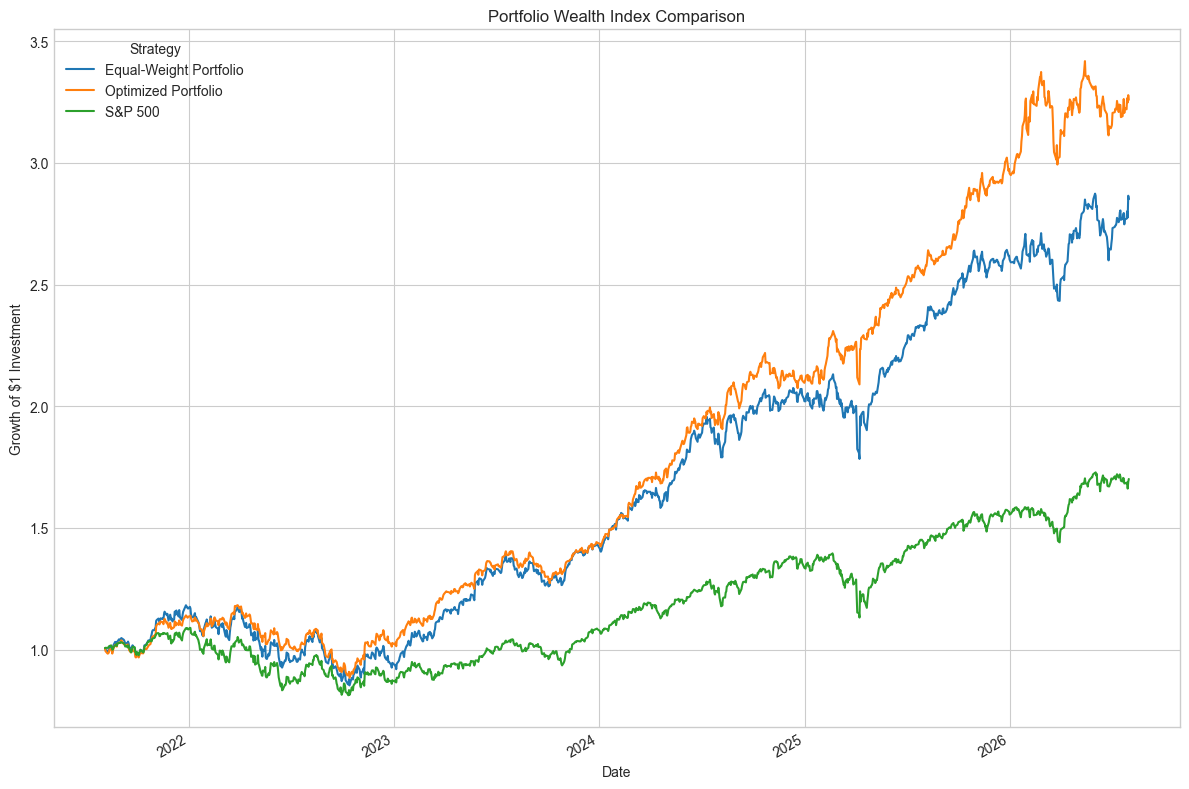

In [47]:
fig, ax = plt.subplots(figsize=(12, 8))

wealth_index.plot(ax=ax)

ax.set_title("Portfolio Wealth Index Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1 Investment")
ax.legend(title="Strategy")

plt.tight_layout()
plt.savefig(
    "project6-backtesting_rebalancing_charts/wealth_index_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

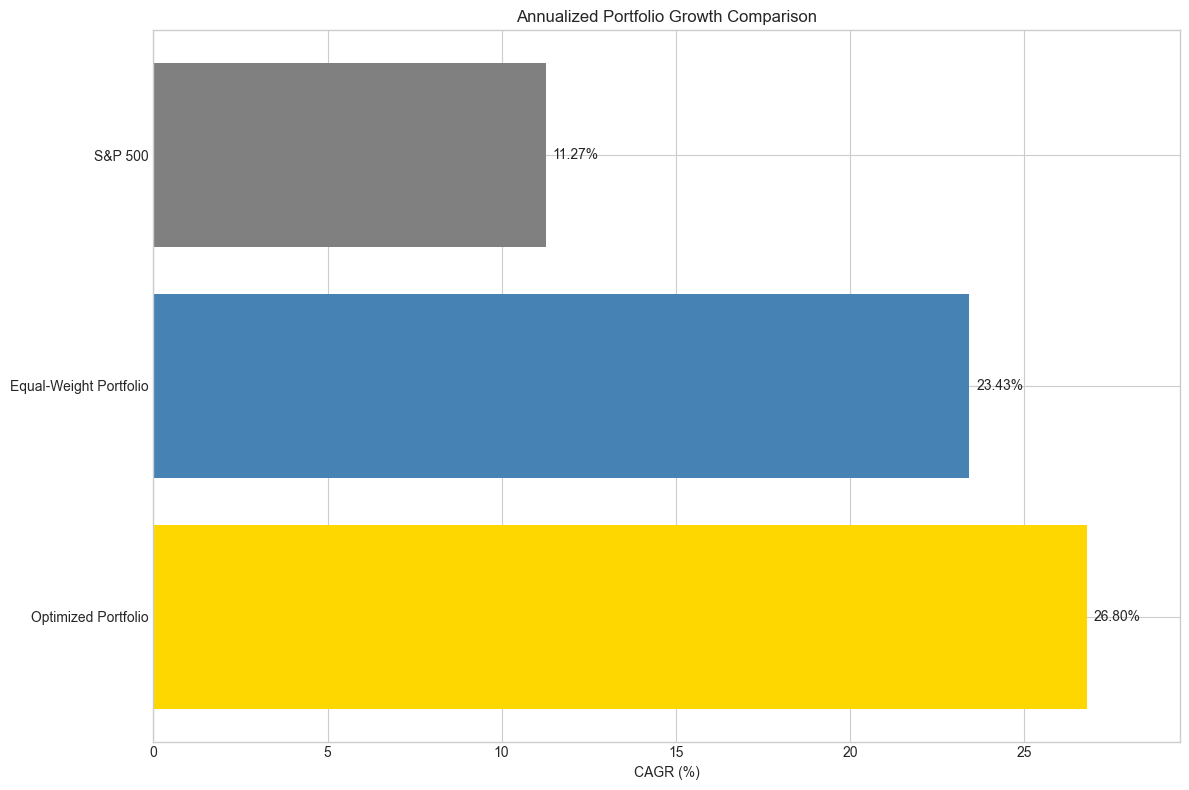

In [48]:
final_wealth = wealth_index.iloc[-1]
years = len(returns)/252

plt.figure(figsize=(12, 8))
cagr = final_wealth**(1/years) - 1
cagr_plot = cagr.sort_values(ascending=False)
plt.barh(cagr_plot.index, (cagr_plot * 100), color=["gold", "steelblue", "gray"])

plt.xlabel("CAGR (%)")
plt.title("Annualized Portfolio Growth Comparison")
plt.xlim(right=1.1*(cagr*100).max())
plt.tight_layout()

for i, value in enumerate(cagr_plot * 100):
    plt.text(value + 0.2, i, f"{value:.2f}%", va="center")

plt.savefig(
    "project6-backtesting_rebalancing_charts/cagr_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
volatilities = strategies.rolling(30).std().dropna()*np.sqrt(252)

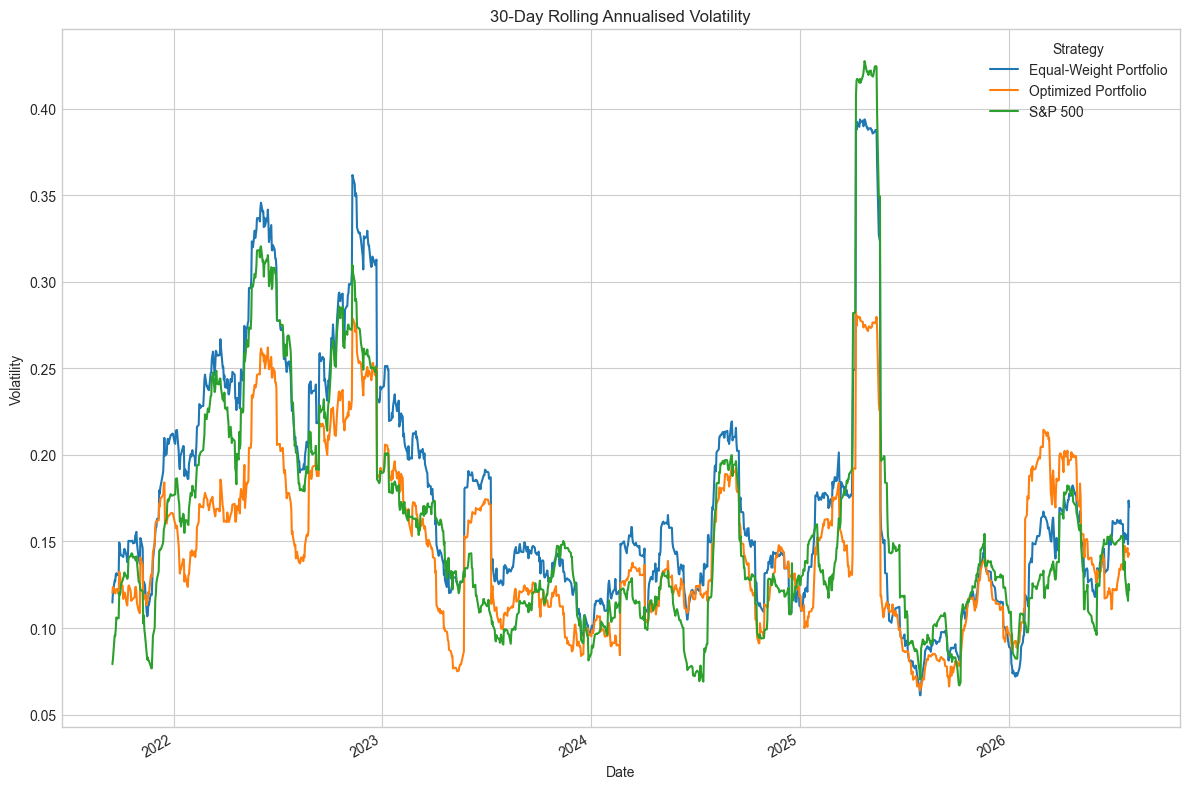

In [50]:
fig, ax = plt.subplots(figsize=(12, 8))

volatilities.plot(ax=ax)

ax.set_title("30-Day Rolling Annualised Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Volatility")
ax.legend(title="Strategy")

plt.tight_layout()
plt.savefig(
    "project6-backtesting_rebalancing_charts/volatility_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

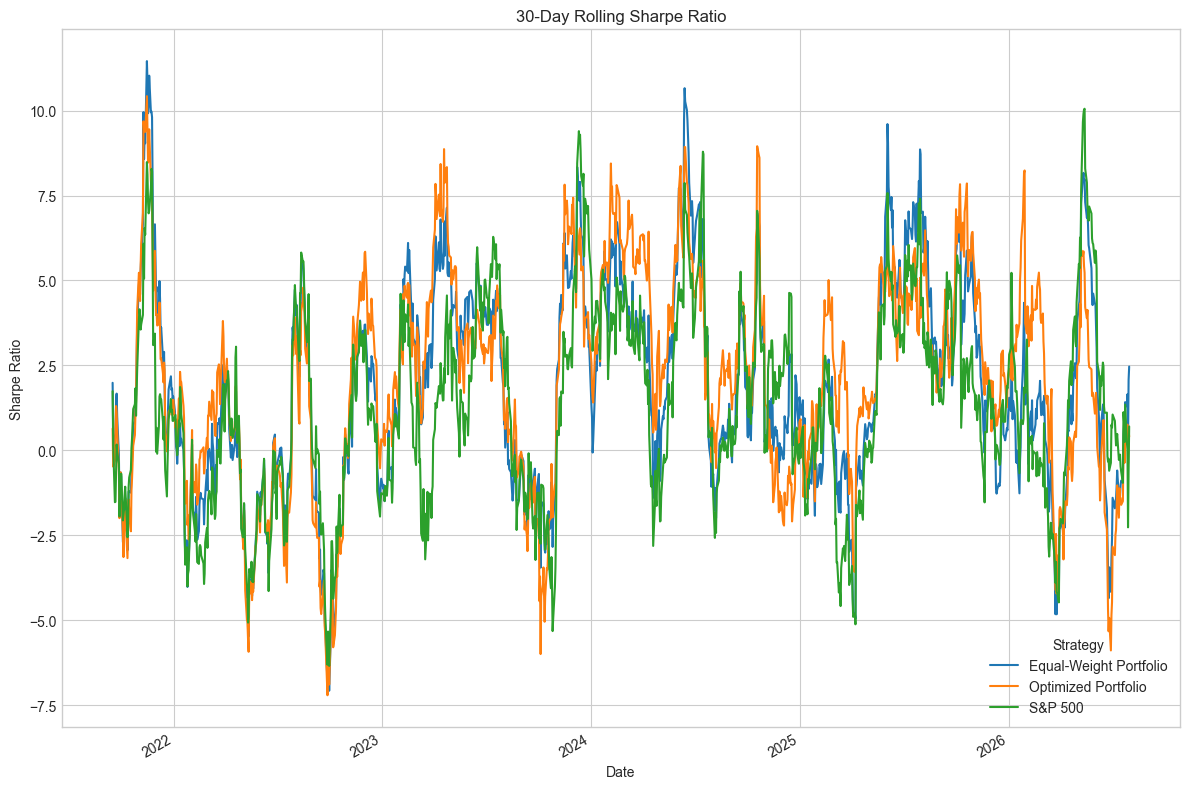

In [51]:
sharpes = strategies.rolling(30).mean()*252/volatilities

fig, ax = plt.subplots(figsize=(12, 8))

sharpes.plot(ax=ax)

ax.set_title("30-Day Rolling Sharpe Ratio")
ax.set_xlabel("Date")
ax.set_ylabel("Sharpe Ratio")
ax.legend(title="Strategy")

plt.tight_layout()
plt.savefig(
    "project6-backtesting_rebalancing_charts/sharpe_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

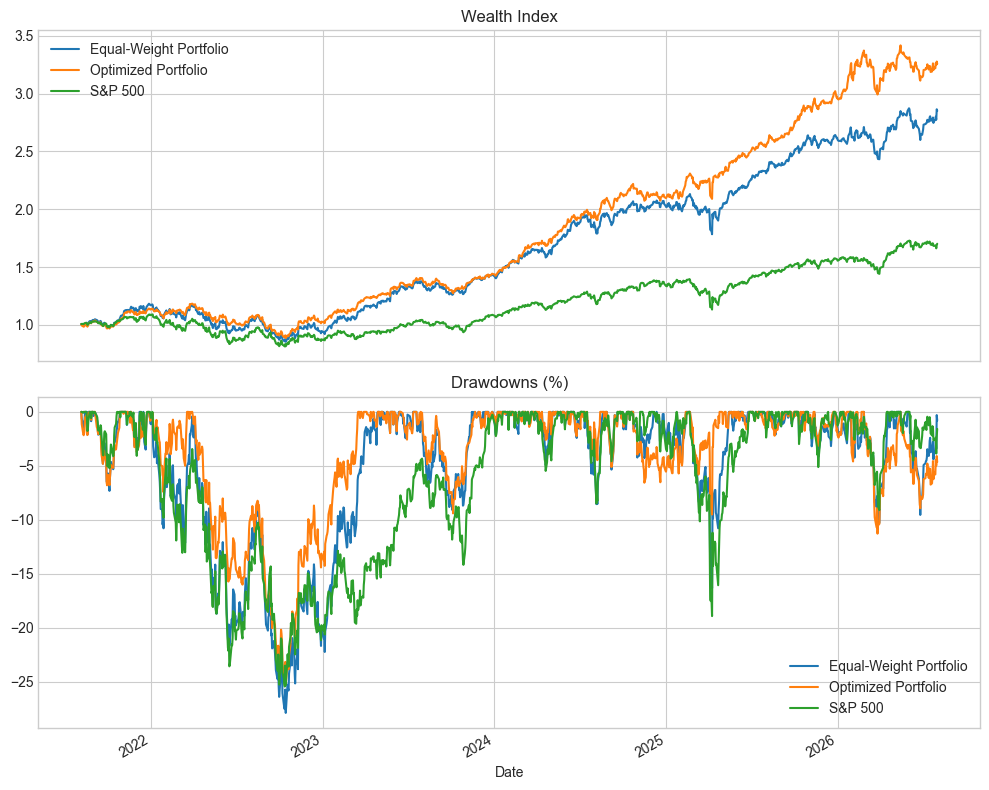

In [52]:
peaks = wealth_index.cummax()
drawdowns = (wealth_index - peaks)/peaks
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,8),sharex = True)
wealth_index.plot(ax=ax1)
ax1.set_title("Wealth Index")
(drawdowns*100).plot(ax=ax2)
ax2.set_title("Drawdowns (%)")

plt.tight_layout()
plt.savefig("project6-backtesting_rebalancing_charts/wealthindex_drawdowns.png")
plt.show()

In [ ]:
def run_backtest(rebalance_frequency):
    rebalancing = returns.copy()
    current_weights = optimized_weights.copy()
    rebalancing_dates = rebalancing.resample(rebalance_frequency).last().index

    daily_returns = []
    for i in range(len(rebalancing)):
        date = rebalancing.index[i]
        current_returns = rebalancing.iloc[i]

        portfolio_return = current_weights @ current_returns
        daily_returns.append(portfolio_return)
        current_weights *= (1 + current_returns)
        current_weights /= current_weights.sum()

        if date in rebalancing_dates:
            current_weights = optimized_weights.copy()

    return pd.Series(
        daily_returns,
        index=rebalancing.index,
        name=f"{rebalance_frequency} Rebalanced Portfolio"
    )

In [ ]:
def metrics(returns):
    wealth = (1 + returns).cumprod()
    volatility = returns.rolling(30).std() * np.sqrt(252)
    cagr = wealth.iloc[-1] ** (1 / years) - 1
    sharpe = returns.rolling(30).mean() * 252 / volatility
    drawdowns = (wealth - wealth.cummax()) / wealth.cummax()

    return wealth, volatility, cagr, sharpe, drawdowns

In [ ]:
monthly_rebalanced_returns  = run_backtest('M')

(
    monthly_rebalanced_wealth, 
    monthly_rebalanced_volatility,
    monthly_rebalanced_cagr,
    monthly_rebalanced_sharpe,
    monthly_rebalanced_drawdowns,
) = metrics(monthly_rebalanced_returns)

C:\Users\yashr\AppData\Local\Temp\ipykernel_17296\1663871147.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  monthly_rebalanced_cagr = monthly_rebalanced_wealth[-1]**(1/years) - 1


In [ ]:
quarterly_rebalanced_returns = run_backtest('Q')

(
    quarterly_rebalanced_wealth, 
    quarterly_rebalanced_volatility,
    quarterly_rebalanced_cagr,
    quarterly_rebalanced_sharpe,
    quarterly_rebalanced_drawdowns,
) = metrics(quarterly_rebalanced_returns)

C:\Users\yashr\AppData\Local\Temp\ipykernel_17296\3774402304.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  quarterly_rebalanced_cagr = quarterly_rebalanced_wealth[-1]**(1/years) - 1


In [62]:
comparison = pd.concat([wealth_index, monthly_rebalanced_wealth, quarterly_rebalanced_wealth], axis = 1)
comparison.round(2).tail()

,Equal-Weight Portfolio,Optimized Portfolio,S&P 500,Monthly Rebalanced Portfolio,Quarterly Rebalanced Portfolio
Date,,,,,
2026-07-27,2.77,3.22,1.68,3.16,3.40
2026-07-28,2.80,3.27,1.69,3.20,3.44
2026-07-29,2.78,3.25,1.66,3.19,3.43
2026-07-30,2.87,3.28,1.69,3.21,3.46
2026-07-31,2.85,3.26,1.70,3.19,3.43


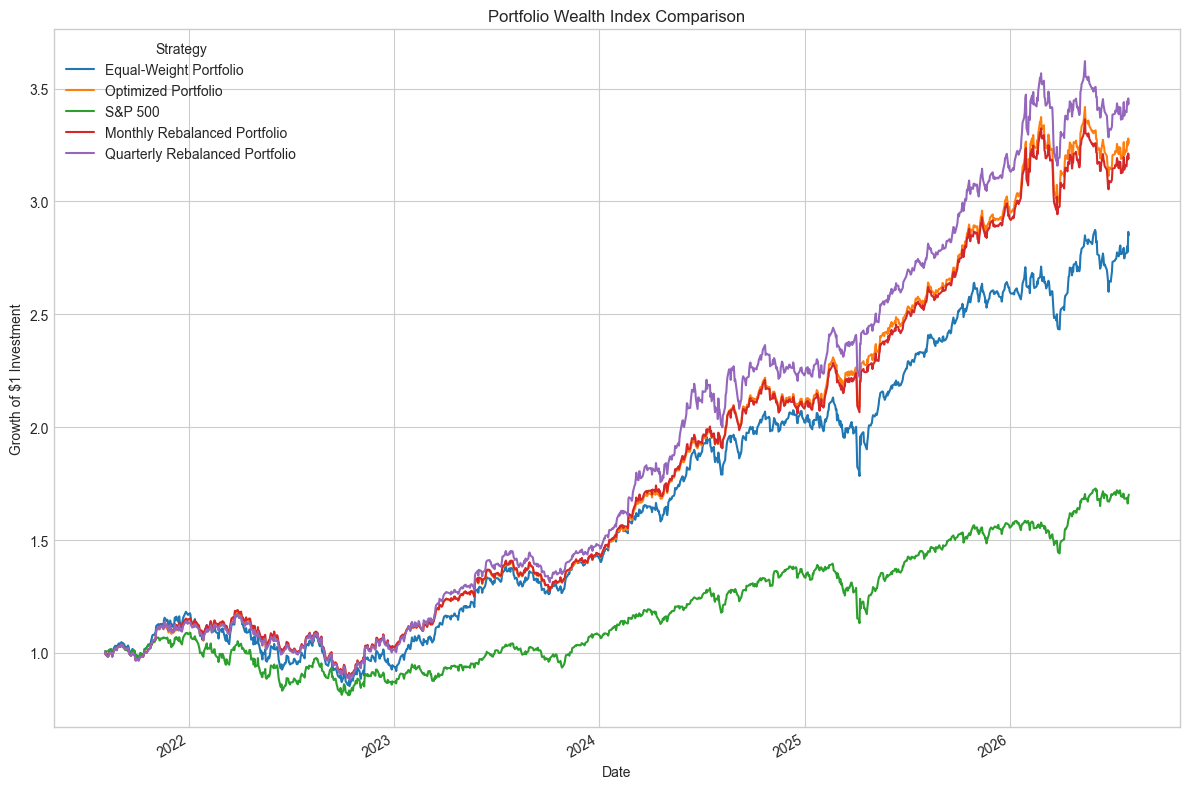

In [59]:
fig, ax = plt.subplots(figsize=(12, 8))

comparison.plot(ax=ax)

ax.set_title("Portfolio Wealth Index Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1 Investment")
ax.legend(title="Strategy")

plt.tight_layout()
plt.savefig(
    "project6-backtesting_rebalancing_charts/final_wealth_index_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [60]:
summary = pd.DataFrame({

    "Final Wealth ($1)": [
        wealth_index["S&P 500"].iloc[-1],
        wealth_index["Equal-Weight Portfolio"].iloc[-1],
        wealth_index["Optimized Portfolio"].iloc[-1],
        monthly_rebalanced_wealth.iloc[-1],
        quarterly_rebalanced_wealth.iloc[-1]
    ],

    "CAGR (%)": [
        cagr["S&P 500"] * 100,
        cagr["Equal-Weight Portfolio"] * 100,
        cagr["Optimized Portfolio"] * 100,
        monthly_rebalanced_cagr * 100,
        quarterly_rebalanced_cagr * 100
    ],

    "Annualized Volatility (%)": [
        volatilities["S&P 500"].mean() * 100,
        volatilities["Equal-Weight Portfolio"].mean() * 100,
        volatilities["Optimized Portfolio"].mean() * 100,
        monthly_rebalanced_volatility.mean() * 100,
        quarterly_rebalanced_volatility.mean() * 100
    ],

    "Sharpe Ratio": [
        sharpes["S&P 500"].mean(),
        sharpes["Equal-Weight Portfolio"].mean(),
        sharpes["Optimized Portfolio"].mean(),
        monthly_rebalanced_sharpe.mean(),
        quarterly_rebalanced_sharpe.mean()
    ],

    "Max Drawdown (%)": [
        drawdowns["S&P 500"].min() * 100,
        drawdowns["Equal-Weight Portfolio"].min() * 100,
        drawdowns["Optimized Portfolio"].min() * 100,
        monthly_rebalanced_drawdowns.min() * 100,
        quarterly_rebalanced_drawdowns.min() * 100
    ]

},
index=[
    "S&P 500",
    "Equal-Weight",
    "Optimized",
    "Monthly Rebalanced",
    "Quarterly Rebalanced"
])

summary = summary.round({
    "Final Wealth ($1)": 2,
    "CAGR (%)": 2,
    "Annualized Volatility (%)": 2,
    "Sharpe Ratio": 3,
    "Max Drawdown (%)": 2
})


                      Final Wealth ($1)  CAGR (%)  Annualized Volatility (%)  \
S&P 500                            1.70     11.27                      15.77   
Equal-Weight                       2.85     23.43                      17.32   
Optimized                          3.26     26.80                      14.67   
Monthly Rebalanced                 3.19     26.26                      14.75   
Quarterly Rebalanced               3.43     28.13                      15.94   

                      Sharpe Ratio  Max Drawdown (%)  
S&P 500                      1.309            -25.43  
Equal-Weight                 1.801            -27.87  
Optimized                    2.086            -25.21  
Monthly Rebalanced           2.006            -25.47  
Quarterly Rebalanced         1.894            -24.65  


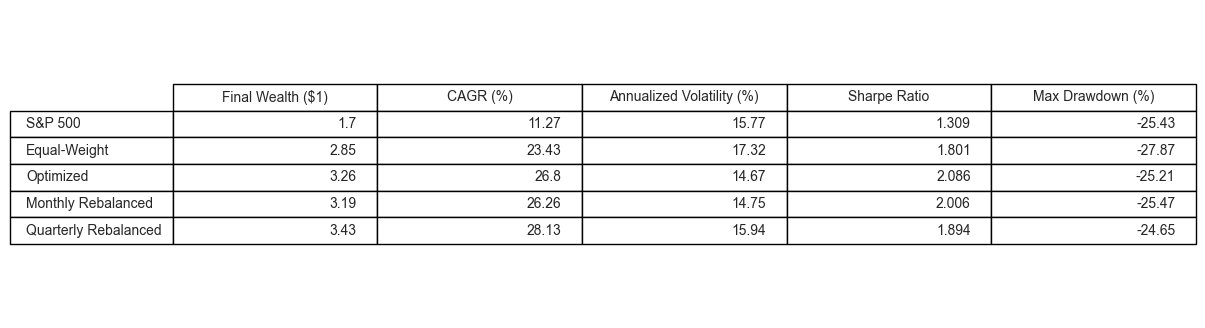

In [61]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.axis("off")

table = ax.table(
    cellText=summary.values,
    rowLabels=summary.index,
    colLabels=summary.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)

plt.savefig(
    "project6-backtesting_rebalancing_charts/performance_summary.png",
    dpi=300,
    bbox_inches="tight"
)

summary.to_csv(
"project6-backtesting_rebalancing_charts/performance_summary.csv"
)

print(summary)